In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../../data/iavd_incidents_raw_target.parquet")


## Блок 3. Кто и откуда: источники, аналитики, пользователи

### 3.1 Сколько уникальных учётных записей в suser?

In [3]:
df['suser'].nunique()

3971

### 3.2 Сколько уникальных пользователей-жертв в Полное имя?

In [4]:
df['Полное имя'].nunique()

1296

### 3.3 Кто из пользователей-жертв фигурирует чаще всего?

In [5]:
df.value_counts('Полное имя').head()

Полное имя
Щукин Александр Евгеньевич      776
Филатов Владимир Николаевич     391
Мишин Никита Владимирович       269
Лучников Павел Александрович    238
Пришвин Александр Леонидович    227
Name: count, dtype: int64

### 3.4 Топ-3 учётных записи suser?

In [6]:
df.value_counts('suser').head(3)

suser
\root             1579
\ankey            1424
\administrator    1378
Name: count, dtype: int64

### 3.5 Сколько уникальных хостов-целей?

In [8]:
df['Hostname Цели'].nunique()

8689

### 3.6 Топ-3 хоста-цели?

In [9]:
df.value_counts('Hostname Цели').head(3)

Hostname Цели
0.0.0.0\\                         4294
\srvSCCM03.iaivd.lan\srvSCCM03    1548
\srvSCCM04.iaivd.lan\srvSCCM04    1541
Name: count, dtype: int64

### 3.7 Сколько аналитиков ведут карточки (Ответственный)?

In [10]:
df['Ответственный'].nunique()

31

### 3.8 Как распределена нагрузка между аналитиками?

In [13]:
r = df.value_counts('Ответственный')
r

Ответственный
Снегирёв Леонид Дмитриевич            24891
Соколов Александр Михайлович          23229
Архипов Евгений Александрович         21444
Коновалов Александр Геннадьевич       16696
Захарова Елизавета Андреевна          16134
Фомина Ульяна Валерьевна              15138
Лебедев Илья Игоревич                 13189
Егоров Алексей Олегович               12366
Судаков Андрей Анатольевич            11833
Шилов Алексей Юрьевич                 10614
Александров Никита Евгеньевич         10418
Цветкова Дарья Дмитриевна             10012
Зайцев Александр Юрьевич               9226
Мешков Алексей Михайлович              7458
                                       6740
Кондратьева Ксения Андреевна           6601
Лемке Илья Олегович                    6586
Архипов Владислав Игоревич             6581
Григорьева Янина Сергеевна             3415
Козлов Павел Сергеевич                 2279
Жданов Андрей Александрович            1433
Панова Алина Юрьевна                   1023
Костин Александр Н

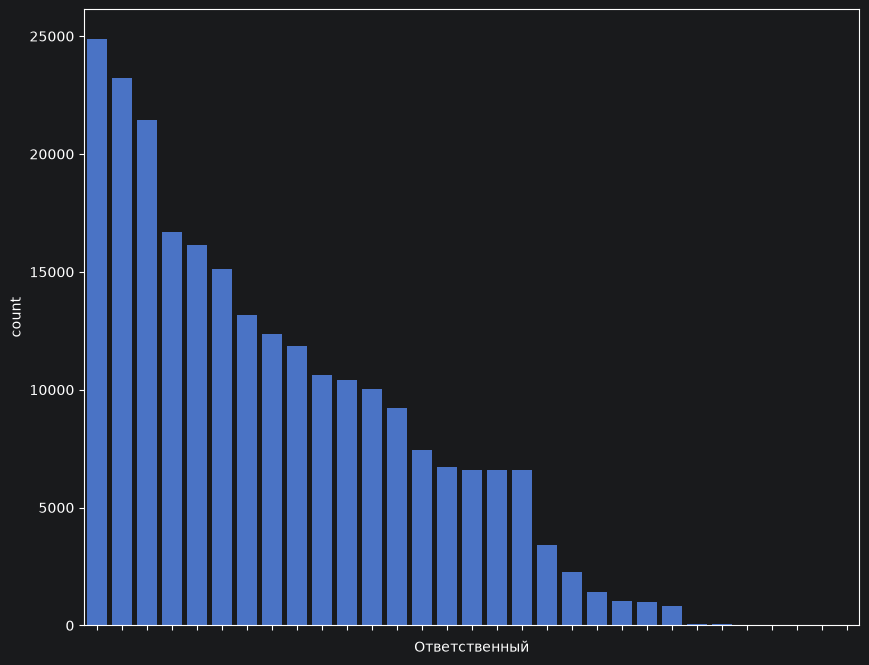

In [24]:
plt.figure(figsize=(10, 8))
ax = sns.barplot(r)
ax.set_xticklabels([])
plt.show()

нагрузка распределена неравномерно: max/min > 10:1

### 3.9 	Как распределены карточки по группам устранения?

In [28]:
df.value_counts('Группа устранения')

Группа устранения
L1     236902
L2       3312
ГИБ        44
Name: count, dtype: int64

### 3.10 Какие значения у Конвейер SIEM?

In [32]:
df.value_counts('Конвейер SIEM', dropna=False)

Конвейер SIEM
ООО "ИАиВД"                               128190
NaN                                        67665
srv-conv1.blinow-a12.iaivd.ru              19351
ГРО ЛО                                      9493
srv-conv02.blinow-a12.iaivd.ru              6823
DataGile                                    4270
МРГ                                         2649
srv-main.blinow-a12.iaivd.ru                1726
Helix                                         60
cyberpoligon-conv1.blinow-a12.iaivd.ru        46
EDR                                           22
Name: count, dtype: int64